In [1]:
import math
import random
import pandas as pd
import numpy as np
import scipy as sp
from scipy import stats
import itertools
from itertools import combinations
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec
from matplotlib import cm
import matplotlib 
%matplotlib inline

In [2]:
! pwd

/Users/alyulina/Projects/Cancer/Code


In [254]:
# data from https://docs.google.com/spreadsheets/d/100QgXtkE5FHj-EFaa64HkjYu8EddSB07/edit#gid=1566829729

# cell line IDs
clIDs = ['AACC', 'AAGG', 'ACAC', 'ACCT', 'ACGA', 'ACTG', 'AGAG', 'AGCA', 'AGGT', 'AGTC', 'ATCG', 'ATGC', 'CAAC', 'CACT', 'CAGA', 'CATG', 'CCAA', 'CCTT', 'CGAT', 'CGTA', 'CTGT', 'CTTC', 'GAAG', 'GATC', 'GCAT', 'GCTA', 'GGAA', 'GGTT', 'GTAC', 'GTGA', 'GTTG', 'TCCA', 'TGAC', 'TGCT', 'TGTG', 'TTCC', 'TTGG']

# cell lines; added numbers (1 and 2) to cell lines w/ identical names
cell_lines = ['mT4-2D', '7160c2', 'FC1199', '6694c2', '7160c5', 'BF857', 'BF1987', 'Panc2', '0688_M', 'FC1245-1', 'BF4326-1', 'BF2117', '6419c5', 'BF4326-2', 'UN-KPC_960-1', '0755_Pancreas', 'BF1836', 'BF2014', 'BF5960', '6499c4', '6422c5', 'FC1245-2', 'KPC_cell_line', 'Spike-in1', 'UN-KPC_960-2', 'BF2153', 'UN-KC-6141', 'mT3-2D', 'mT5-2D', '0764_Pancreas', '6421c2', '0755_Ascites', '2838c3', 'Spike-in2', 'Spike-in3', 'FC1242', 'UN-KPC_961']

clID_dict = dict(zip(clIDs, cell_lines))
cell_line_dict = dict(zip(cell_lines, clIDs))

# samples sequenced in the second run
# samples = ['SK1_' + '{:0.0f}'.format(i) for i in [61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 99, 103, 104, 107, 111, 112, 114]]
samples_pre_inj = ['SK1_' + '{:0.0f}'.format(i) for i in [61, 62, 63, 88, 89, 90, 91, 92, 93]]
samples_3w = ['SK1_' + '{:0.0f}'.format(i) for i in range(1, 45)]
samples_t = ['SK1_' + '{:0.0f}'.format(i) for i in [64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87]]

In [4]:
sample_clID_counts_pre_inj = [] # a list of dictionaries for each sample

for i, sample in enumerate(samples_pre_inj):
    
    sample_clID_counts_pre_inj.append({}) # initiating a dictionary for each sample
    for j in clIDs:
        sample_clID_counts_pre_inj[i][j] = [] # initiating lists for counts for each cell line within a sample
    
    n_sample_spikes_coverage = [0, 0, 0]
    n_sample_cancer_cells_coverage = 0
    for line in open('../Data/bc_counts/novogene_02.22.2023_X202SC23012558-Z01-F001/' + sample + '_merged_clIDs_bc_clusters_counts.txt', 'r'):
        clID_bc, count = line.strip('\n').split()
        # print(clID_bc, count)
        
        if int(count) < 2: # only adding barcodes with at least two reads
            continue
            
        sample_clID_counts_pre_inj[i][clID_bc[:4]].append([clID_bc[5:], int(count)])
    

In [255]:
sample_clID_counts_t = [] # a list of dictionaries for each sample

for i, sample in enumerate(samples_t):
    
    sample_clID_counts_t.append({}) # initiating a dictionary for each sample
    for j in clIDs:
        sample_clID_counts_t[i][j] = [] # initiating lists for counts for each cell line within a sample
    
    n_sample_spikes_coverage = [0, 0, 0]
    n_sample_cancer_cells_coverage = 0
    for line in open('../Data/bc_counts/novogene_02.22.2023_X202SC23012558-Z01-F001/' + sample + '_merged_clIDs_bc_clusters_counts.txt', 'r'):
        clID_bc, count = line.strip('\n').split()
        # print(clID_bc, count)
        
        if int(count) < 2: # only adding barcodes with at least two reads
            continue
            
        sample_clID_counts_t[i][clID_bc[:4]].append([clID_bc[5:], int(count)])
    

In [5]:
sample_clID_counts_3w = [] # a list of dictionaries for each sample

for i, sample in enumerate(samples_3w):
    
    sample_clID_counts_3w.append({}) # initiating a dictionary for each sample
    for j in clIDs:
        sample_clID_counts_3w[i][j] = [] # initiating lists for counts for each cell line within a sample
    
    n_sample_spikes_coverage = [0, 0, 0]
    n_sample_cancer_cells_coverage = 0
    for line in open('../Data/bc_counts/novogene_01.09.2023_X202SC22123847-Z01-F001/' + sample + '_merged_clIDs_bc_clusters_counts.txt', 'r'):
        clID_bc, count = line.strip('\n').split()
        # print(clID_bc, count)
        
        if int(count) < 2: # only adding barcodes with at least two reads
            continue
            
        sample_clID_counts_3w[i][clID_bc[:4]].append([clID_bc[5:], int(count)])
    

In [6]:
# cancer reads per sample
n_reads_cancer_cells_pre_inj = {}
for i, sample in enumerate(samples_pre_inj):
    
    counts = 0
    for j in clIDs:
        if clID_dict.get(j)[:5] != 'Spike':
            counts += sum([x[-1] for x in sample_clID_counts_pre_inj[i][j]])
            
    n_reads_cancer_cells_pre_inj[sample] = counts     

In [256]:
# cancer reads per sample
n_reads_cancer_cells_t = {}
for i, sample in enumerate(samples_t):
    
    counts = 0
    for j in clIDs:
        if clID_dict.get(j)[:5] != 'Spike':
            counts += sum([x[-1] for x in sample_clID_counts_t[i][j]])
            
    n_reads_cancer_cells_t[sample] = counts     

In [7]:
# cancer reads per sample
n_reads_cancer_cells_3w = {}
for i, sample in enumerate(samples_3w):
    
    counts = 0
    for j in clIDs:
        if clID_dict.get(j)[:5] != 'Spike':
            counts += sum([x[-1] for x in sample_clID_counts_3w[i][j]])
            
    n_reads_cancer_cells_3w[sample] = counts     

In [8]:
# 61, 62, 63 are the pre-injection pools (in triplicate)
# 88, 89 are SK1865 rep. 2 and 3
# 90, 91 are SK1879 rep. 2 and 3
# 92, 93 are SK1869 rep. 2 and 3

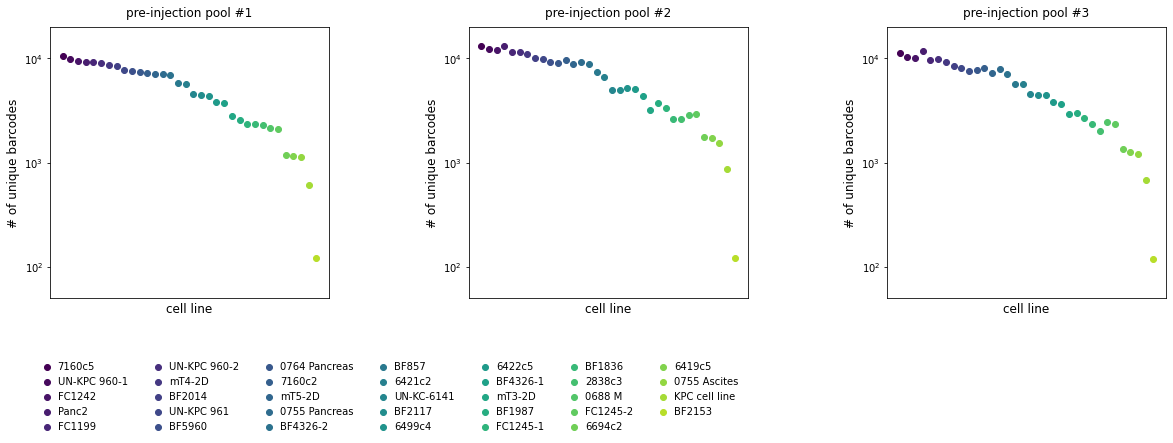

In [9]:
viridis = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=len(cell_lines)), 
                                       cmap=plt.get_cmap('viridis'))

plasma = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=5), 
                                       cmap=plt.get_cmap('plasma'))

colors = ['#b83089', '#da5a67', '#ec7a52'] # for spike-ins

plt.figure(figsize=(20, 5))

grid = gridspec.GridSpec(ncols=3, nrows=1,
                         width_ratios=[1, 1, 1], wspace=0.5,
                         height_ratios=[1], hspace=0.5)

c = 0
cell_line_fracs_sample = []
for i in range(len(samples_pre_inj[:3])):
    
    plt.subplot(grid[c // 3, c % 3])
    
    
    # cell line order based on sample 1
    order = [4, 14, 35, 7, 2, 24, 0, 17, 36, 18, 29, 1, 28, 15, 13, 5, 30, 26, 11, 19, 20, 10, 27, 6, 9, 16, 32, 8, 21, 3, 12, 31, 22, 25]
    
    for count, j in enumerate(order):
        
        if cell_lines[j][:5] != 'Spike':
            n_unique_bc = len(sample_clID_counts_pre_inj[i][clIDs[j]])
            plt.scatter(count, n_unique_bc, label=cell_lines[j].replace('_', ' '), color=viridis.to_rgba(count))
    
    plt.yscale('log'); plt.minorticks_off()
    plt.ylim(5e1, 2e4)
    # plt.xlim(0, 200)
    # plt.yticks([1, 500, 1000, 1500, 2000], ['$0$', '$500$', '$1000$', '$1500$', '$2000$'], fontsize=10)
    plt.xticks([], [])
    
    if i == 1:
        plt.legend(frameon=False, ncol=7, handletextpad=0.1, bbox_to_anchor=(1, -0.2))
    
    
    plt.title('pre-injection pool #' + str(i + 1), fontsize=12, pad=10)
    plt.xlabel('cell line', fontsize=12)
    plt.ylabel('# of unique barcodes', fontsize=12)
      
    c += 1

    
# plt.savefig('pre-inj_n_unique_bc_reps.png', dpi=300, bbox_inches='tight')

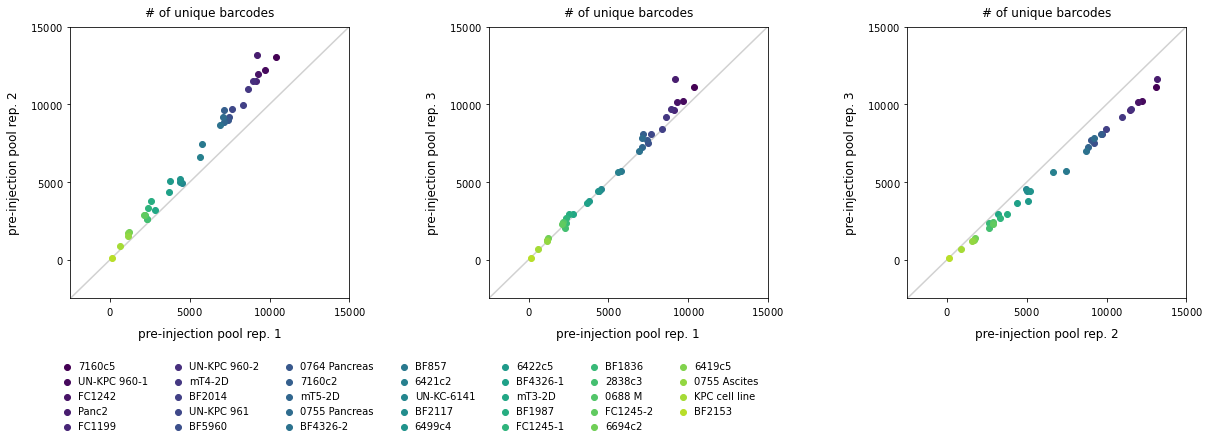

In [10]:
viridis = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=len(cell_lines)), 
                                       cmap=plt.get_cmap('viridis'))

plasma = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=5), 
                                       cmap=plt.get_cmap('plasma'))

colors = ['#b83089', '#da5a67', '#ec7a52'] # for spike-ins

plt.figure(figsize=(20, 5))

grid = gridspec.GridSpec(ncols=3, nrows=1,
                         width_ratios=[1, 1, 1], wspace=0.5,
                         height_ratios=[1], hspace=0.5)

c = 0
cell_line_fracs_sample = []
for i in itertools.combinations([0, 1, 2], 2):
    
    plt.subplot(grid[c // 3, c % 3])
    plt.plot([-2500, 15000], [-2500, 15000], color='#d1d1d1', zorder=0)
    
    
    # cell line order based on sample 1
    order = [4, 14, 35, 7, 2, 24, 0, 17, 36, 18, 29, 1, 28, 15, 13, 5, 30, 26, 11, 19, 20, 10, 27, 6, 9, 16, 32, 8, 21, 3, 12, 31, 22, 25]
    
    for count, j in enumerate(order):
        
        if cell_lines[j][:5] != 'Spike':
            n_unique_bc = [len(sample_clID_counts_pre_inj[i[0]][clIDs[j]]), len(sample_clID_counts_pre_inj[i[1]][clIDs[j]])]
            plt.scatter(n_unique_bc[0], n_unique_bc[1], label=cell_lines[j].replace('_', ' '), color=viridis.to_rgba(count))
    
    
    plt.xlim(-2500, 15000)
    plt.ylim(-2500, 15000)
    plt.xticks([0, 5000, 10000, 15000], ['$0$', '$5000$', '$10000$', '$15000$'], fontsize=10)
    plt.yticks([0, 5000, 10000, 15000], ['$0$', '$5000$', '$10000$', '$15000$'], fontsize=10)

    
    if c == 1:
        plt.legend(frameon=False, ncol=7, handletextpad=0.1, bbox_to_anchor=(1, -0.2))
    
    
    plt.title('# of unique barcodes', fontsize=12, pad=10)
    plt.xlabel('pre-injection pool rep. ' + str(i[0] + 1), fontsize=12, labelpad=10)
    plt.ylabel('pre-injection pool rep. ' + str(i[1] + 1), fontsize=12, labelpad=10)
      
    c += 1

    
# plt.savefig('pre-inj_n_unique_bc_reps_corr.png', dpi=300, bbox_inches='tight')

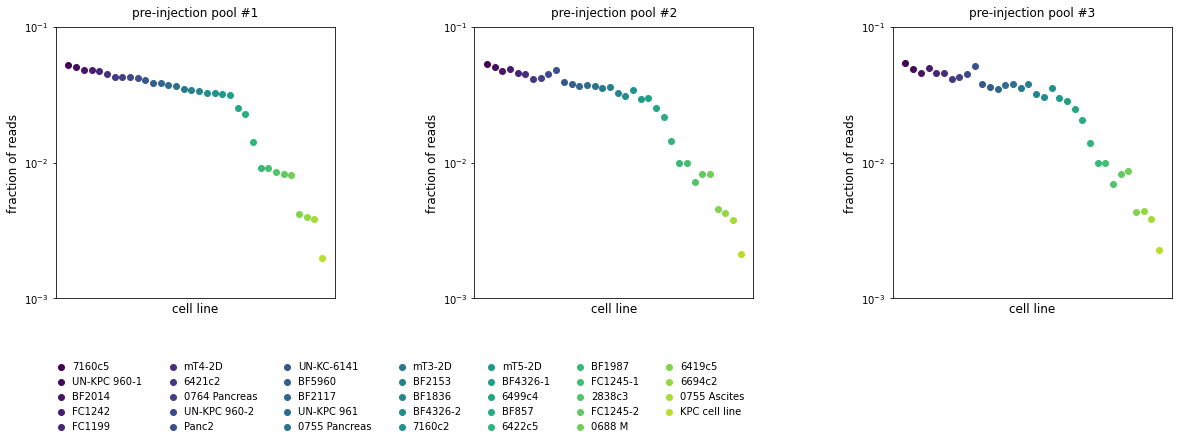

In [11]:
viridis = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=len(cell_lines)), 
                                       cmap=plt.get_cmap('viridis'))

plasma = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=5), 
                                       cmap=plt.get_cmap('plasma'))

colors = ['#b83089', '#da5a67', '#ec7a52'] # for spike-ins

plt.figure(figsize=(20, 5))

grid = gridspec.GridSpec(ncols=3, nrows=1,
                         width_ratios=[1, 1, 1], wspace=0.5,
                         height_ratios=[1], hspace=0.5)

c = 0
cell_line_fracs_sample = []
for i in range(len(samples_pre_inj[:3])):
    
    plt.subplot(grid[c // 3, c % 3])
    
    total_coverage = n_reads_cancer_cells_pre_inj[samples_pre_inj[i]] # ignoring the spiker -- there should be no barcodes
    
    
    # cell line order based on sample 1 - not the same as before!!!
    order = [4, 14, 17, 35, 2, 0, 30, 29, 24, 7, 26, 18, 11, 36, 15, 27, 25, 16, 13, 1, 28, 10, 19, 5, 20, 6, 9, 32, 21, 8, 12, 3, 31, 22, 34, 23, 33]
    
    for count, j in enumerate(order):
        
        if cell_lines[j][:5] != 'Spike':
            n_bc_total = np.sum([x[-1] for x in sample_clID_counts_pre_inj[i][clIDs[j]]])
            plt.scatter(count, n_bc_total / total_coverage, label=cell_lines[j].replace('_', ' '), color=viridis.to_rgba(count))
    
    plt.yscale('log'); plt.minorticks_off()
    plt.ylim(1e-3, 1e-1)
    # plt.xlim(0, 200)
    # plt.yticks([1, 500, 1000, 1500, 2000], ['$0$', '$500$', '$1000$', '$1500$', '$2000$'], fontsize=10)
    plt.xticks([], [])
    
    if i == 1:
        plt.legend(frameon=False, ncol=7, handletextpad=0.1, bbox_to_anchor=(1, -0.2))
    
    
    plt.title('pre-injection pool #' + str(i + 1), fontsize=12, pad=10)
    plt.xlabel('cell line', fontsize=12)
    plt.ylabel('fraction of reads', fontsize=12)
      
    c += 1

    
# plt.savefig('pre-inj_frac_bc.png', dpi=300, bbox_inches='tight')

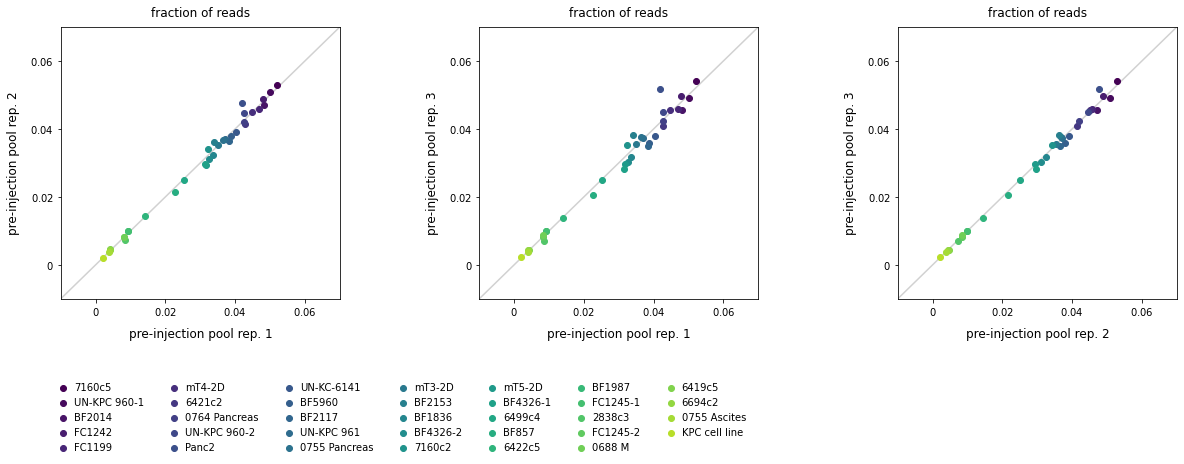

In [14]:
viridis = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=len(cell_lines)), 
                                       cmap=plt.get_cmap('viridis'))

plasma = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=5), 
                                       cmap=plt.get_cmap('plasma'))

colors = ['#b83089', '#da5a67', '#ec7a52'] # for spike-ins

plt.figure(figsize=(20, 5))

grid = gridspec.GridSpec(ncols=3, nrows=1,
                         width_ratios=[1, 1, 1], wspace=0.5,
                         height_ratios=[1], hspace=0.5)

c = 0
cell_line_fracs_sample = []
for i in itertools.combinations([0, 1, 2], 2):
    
    plt.subplot(grid[c // 3, c % 3])
    plt.plot([-10, 10], [-10, 10], color='#d1d1d1', zorder=0)
    
    
    total_coverage = [n_reads_cancer_cells_pre_inj[samples_pre_inj[i[0]]], n_reads_cancer_cells_pre_inj[samples_pre_inj[i[1]]]] # ignoring the spikes -- there should be no barcodes
    
    
    # cell line order based on sample 1 - not the same as before!!!
    order = [4, 14, 17, 35, 2, 0, 30, 29, 24, 7, 26, 18, 11, 36, 15, 27, 25, 16, 13, 1, 28, 10, 19, 5, 20, 6, 9, 32, 21, 8, 12, 3, 31, 22]
    
    for count, j in enumerate(order):

        
        if cell_lines[j][:5] != 'Spike':
            n_bc_total = [np.sum([x[-1] for x in sample_clID_counts_pre_inj[i[0]][clIDs[j]]]), np.sum([x[-1] for x in sample_clID_counts_pre_inj[i[1]][clIDs[j]]])]
            plt.scatter(n_bc_total[0] / total_coverage[0], n_bc_total[1] / total_coverage[1], label=cell_lines[j].replace('_', ' '), color=viridis.to_rgba(count))
 

    plt.xlim(-0.01, 0.07)
    plt.ylim(-0.01, 0.07)
    plt.xticks([0, 0.02, 0.04, 0.06], ['$0$', '$0.02$', '$0.04$', '$0.06$'], fontsize=10)
    plt.yticks([0, 0.02, 0.04, 0.06], ['$0$', '$0.02$', '$0.04$', '$0.06$'], fontsize=10)

    
    if c == 0:
        plt.legend(frameon=False, ncol=7, handletextpad=0.1, bbox_to_anchor=(-0.06, -0.6), loc='lower left')
    
    
    plt.title('fraction of reads', fontsize=12, pad=10)
    plt.xlabel('pre-injection pool rep. ' + str(i[0] + 1), fontsize=12, labelpad=10)
    plt.ylabel('pre-injection pool rep. ' + str(i[1] + 1), fontsize=12, labelpad=10)
      
    c += 1

    
# plt.savefig('pre-inj_frac_bc_reps_corr.png', dpi=300, bbox_inches='tight')

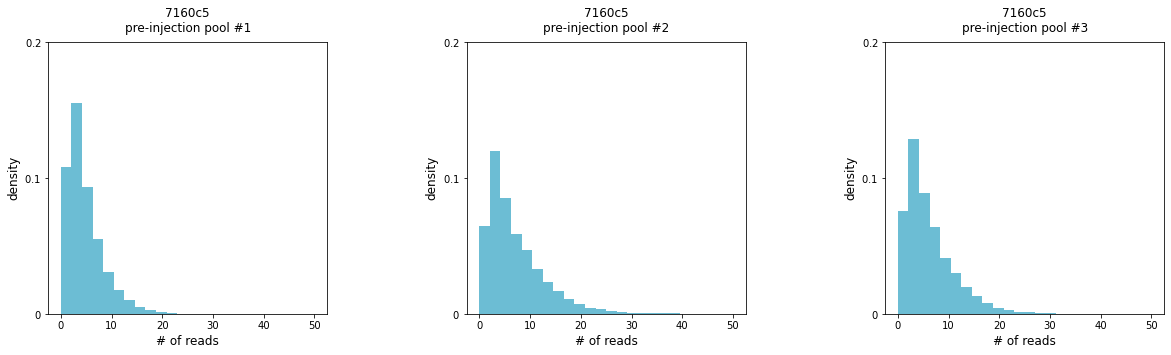

In [359]:
viridis = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=len(cell_lines)), 
                                       cmap=plt.get_cmap('viridis'))

plasma = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=5), 
                                       cmap=plt.get_cmap('plasma'))

colors = ['#b83089', '#da5a67', '#ec7a52'] # for spike-ins

plt.figure(figsize=(20, 5))

grid = gridspec.GridSpec(ncols=3, nrows=1,
                         width_ratios=[1, 1, 1], wspace=0.5,
                         height_ratios=[1], hspace=0.5)

c = 0
cell_line_fracs_sample = []
for i in range(len(samples_pre_inj[:3])):
    
    plt.subplot(grid[c // 3, c % 3])
    
    
    j = 4
        
    if cell_lines[j][:5] != 'Spike':
        plt.hist([x[-1] for x in sample_clID_counts_pre_inj[i][clIDs[j]]], color='#6cbdd4', density=True, bins=np.linspace(0,50,25))
        # print(sorted([x[-1] for x in sample_clID_counts_pre_inj[i][clIDs[j]]]))
    #plt.yscale('log'); plt.minorticks_off()
    #plt.ylim(1e-3, 1e-1)
    plt.ylim(0, 0.2)
    plt.yticks([0, 0.1, 0.2], ['$0$', '$0.1$', '$0.2$'], fontsize=10)
    #plt.xticks([], [])
    
    #if i == 1:
    #    plt.legend(frameon=False, ncol=7, handletextpad=0.1, bbox_to_anchor=(1, -0.2))
    
    
    plt.title(cell_lines[j].replace('_', ' ') + '\n' + 'pre-injection pool #' + str(i + 1), fontsize=12, pad=10)
    plt.xlabel('# of reads', fontsize=12)
    plt.ylabel('density', fontsize=12)
      
    c += 1

    
#plt.savefig('pre-inj_bc_distr_' + cell_lines[j] + '.png', dpi=300, bbox_inches='tight')

Text(0, 0.5, '# of reads')

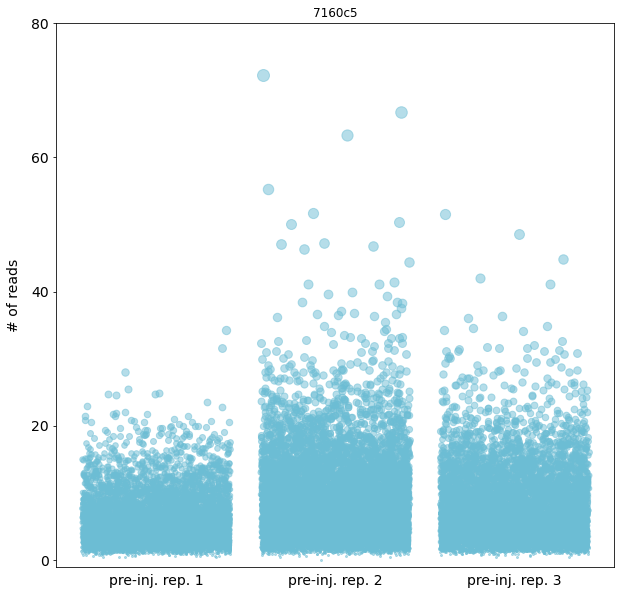

In [468]:
plt.figure(figsize=(10, 10))

#grid = gridspec.GridSpec(ncols=3, nrows=1,
#                         width_ratios=[1, 1, 1], wspace=0.2,
#                         height_ratios=[1], hspace=0.5)

for sample_i in range(3):
    
    #plt.subplot(grid[c // 3, c % 3])

    cl_7160c5_bc = [x[-1] for x in sample_clID_counts_pre_inj[sample_i][clIDs[4]]]
    cl_7160c5_bc_counts = [[x, cl_7160c5_bc.count(x)] for x in set(cl_7160c5_bc)] 

    for i in cl_7160c5_bc_counts:
        plt.scatter(np.random.uniform(1.2 * sample_i, 1.2 * sample_i + 1, i[-1]), np.random.normal(i[0], 0.5, i[-1]), color='#6cbdd4', edgecolors=None,
                    s=2*i[0], alpha=0.5)
                    #alpha=i[0]/cl_7160c5_bc_counts[-1][0])
            
plt.ylim(-1, 80)
    #plt.axis('off')
        
plt.xticks([0.5, 1.7, 2.9], ['pre-inj. rep. 1', 'pre-inj. rep. 2', 'pre-inj. rep. 3'], size=14);
plt.yticks([0, 20, 40, 60, 80], [0, 20, 40, 60, 80], size=14);

plt.tick_params(bottom=False)
plt.title(cell_lines[4])
plt.ylabel('# of reads', size=14, labelpad=10);
  
        
# plt.savefig('pre-inj_bc_distr_scatter_' + cell_lines[4] + '.png', dpi=300, bbox_inches='tight')


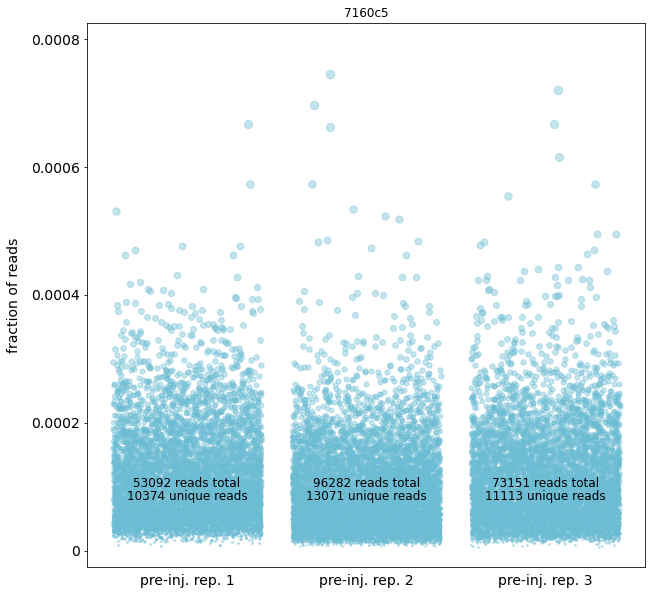

In [486]:
plt.figure(figsize=(10, 10))

#grid = gridspec.GridSpec(ncols=3, nrows=1,
#                         width_ratios=[1, 1, 1], wspace=0.2,
#                         height_ratios=[1], hspace=0.5)

for sample_i in range(3):
    
    #plt.subplot(grid[c // 3, c % 3])

    cl_7160c5_bc = [x[-1] for x in sample_clID_counts_pre_inj[sample_i][clIDs[4]]]
    cl_7160c5_bc_counts = [[x, cl_7160c5_bc.count(x)] for x in set(cl_7160c5_bc)] 

    for i in cl_7160c5_bc_counts:
        plt.scatter(np.random.uniform(1.2 * sample_i, 1.2 * sample_i + 1, i[-1]), [max(x, 0) for x in np.random.normal(i[0] / sum(cl_7160c5_bc), 0.5 / sum(cl_7160c5_bc), i[-1])], color='#6cbdd4', edgecolors=None,
                    s=1e5*i[0] / sum(cl_7160c5_bc), alpha=0.4)
                    #alpha=i[0]/cl_7160c5_bc_counts[-1][0])
    
    plt.text(1.2 * sample_i + 0.5, 0.0001, str(sum(cl_7160c5_bc)) + ' reads total', size=12, ha='center');
    plt.text(1.2 * sample_i + 0.5, 0.00008, str(sum([x[-1] for x in cl_7160c5_bc_counts])) + ' unique reads', size=12, ha='center');

            
plt.ylim(-0.000025, 0.000825)
#plt.axis('off')
        
plt.xticks([0.5, 1.7, 2.9], ['pre-inj. rep. 1', 'pre-inj. rep. 2', 'pre-inj. rep. 3'], size=14);
plt.yticks([0, 0.0002, 0.0004, 0.0006, 0.0008], [0, 0.0002, 0.0004, 0.0006, 0.0008], size=14);
#plt.yticks([], [])

plt.tick_params(bottom=False)
plt.title(cell_lines[4])
plt.ylabel('fraction of reads', size=14, labelpad=10);

   
        
# plt.savefig('pre-inj_bc_distr_scatter_normalized_' + cell_lines[4] + '.png', dpi=300, bbox_inches='tight')



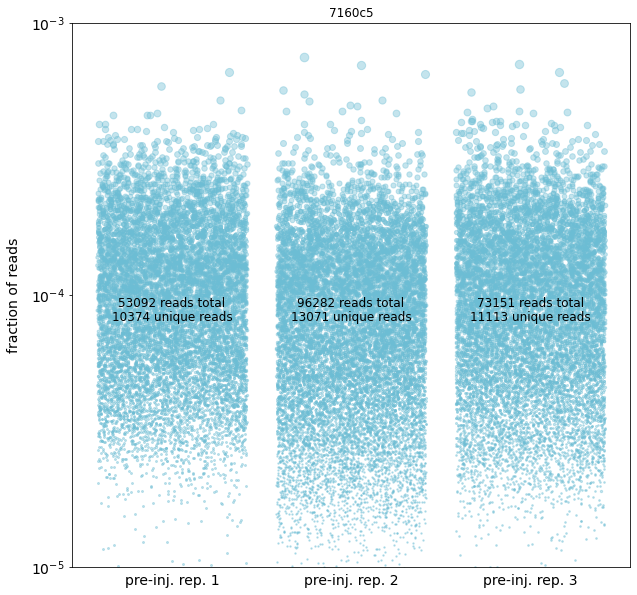

In [514]:
plt.figure(figsize=(10, 10))

#grid = gridspec.GridSpec(ncols=3, nrows=1,
#                         width_ratios=[1, 1, 1], wspace=0.2,
#                         height_ratios=[1], hspace=0.5)

for sample_i in range(3):
    
    #plt.subplot(grid[c // 3, c % 3])

    cl_7160c5_bc = [x[-1] for x in sample_clID_counts_pre_inj[sample_i][clIDs[4]]]
    cl_7160c5_bc_counts = [[x, cl_7160c5_bc.count(x)] for x in set(cl_7160c5_bc)] 

    for i in cl_7160c5_bc_counts:
        plt.scatter(np.random.uniform(1.2 * sample_i, 1.2 * sample_i + 1, i[-1]), [x for x in np.random.normal(i[0] / sum(cl_7160c5_bc), 0.5 / sum(cl_7160c5_bc), i[-1])], color='#6cbdd4', edgecolors=None,
                    s=1e5*i[0] / sum(cl_7160c5_bc), alpha=0.4)
                    #alpha=i[0]/cl_7160c5_bc_counts[-1][0])
    
    plt.text(1.2 * sample_i + 0.5, 0.00009, str(sum(cl_7160c5_bc)) + ' reads total', size=12, ha='center');
    plt.text(1.2 * sample_i + 0.5, 0.00008, str(sum([x[-1] for x in cl_7160c5_bc_counts])) + ' unique reads', size=12, ha='center');

            
#plt.ylim(-0.000025, 0.000825)
plt.ylim(1e-5, 1e-3)
#plt.axis('off')
        
plt.xticks([0.5, 1.7, 2.9], ['pre-inj. rep. 1', 'pre-inj. rep. 2', 'pre-inj. rep. 3'], size=14);
#plt.yticks([0, 0.0002, 0.0004, 0.0006, 0.0008], [0, 0.0002, 0.0004, 0.0006, 0.0008], size=14);
plt.yticks([1e-5, 1e-4, 1e-3], [1e-5, 1e-4, 1e-3], size=14)

plt.yscale('log'); plt.minorticks_off()

plt.tick_params(bottom=False)
plt.title(cell_lines[4])
plt.ylabel('fraction of reads', size=14, labelpad=10);

   
        
# plt.savefig('pre-inj_bc_distr_scatter_normalized_' + cell_lines[4] + '.png', dpi=300, bbox_inches='tight')



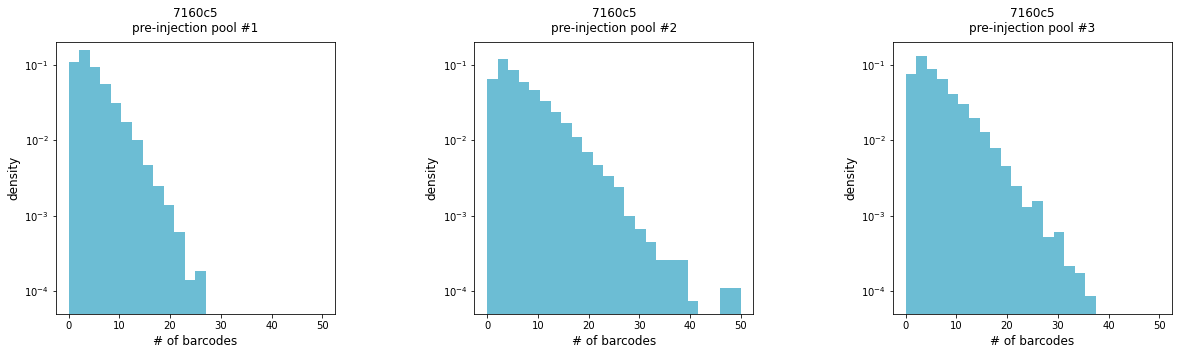

In [16]:
viridis = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=len(cell_lines)), 
                                       cmap=plt.get_cmap('viridis'))

plasma = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=5), 
                                       cmap=plt.get_cmap('plasma'))

colors = ['#b83089', '#da5a67', '#ec7a52'] # for spike-ins

plt.figure(figsize=(20, 5))

grid = gridspec.GridSpec(ncols=3, nrows=1,
                         width_ratios=[1, 1, 1], wspace=0.5,
                         height_ratios=[1], hspace=0.5)

c = 0
cell_line_fracs_sample = []
for i in range(len(samples_pre_inj[:3])):
    
    plt.subplot(grid[c // 3, c % 3])
    
    
    j = 4
        
    if cell_lines[j][:5] != 'Spike':
        plt.hist([x[-1] for x in sample_clID_counts_pre_inj[i][clIDs[j]]], color='#6cbdd4', density=True, bins=np.linspace(0,50,25))
      
    plt.yscale('log'); plt.minorticks_off()
    plt.ylim(5e-5, 2e-1)
    #plt.ylim(0, 0.2)
    #plt.yticks([0, 0.1, 0.2], ['$0$', '$0.1$', '$0.2$'], fontsize=10)
    #plt.xticks([], [])
    
    #if i == 1:
    #    plt.legend(frameon=False, ncol=7, handletextpad=0.1, bbox_to_anchor=(1, -0.2))
    
    
    plt.title(cell_lines[j].replace('_', ' ') + '\n' + 'pre-injection pool #' + str(i + 1), fontsize=12, pad=10)
    plt.xlabel('# of reads', fontsize=12)
    plt.ylabel('density', fontsize=12)
      
    c += 1

    
#plt.savefig('pre-inj_bc_distr_' + cell_lines[j] + '_log.png', dpi=300, bbox_inches='tight')

In [ ]:
# comparing fracs of reads w/ 3 week mice:

In [40]:
cell_line_fracs_sample_pre_inj = []
for i in range(len(samples_pre_inj)):
    
    total_coverage = n_reads_cancer_cells_pre_inj[samples_pre_inj[i]] # excluding spike-ins
    
    # cell line order based on sample 24
    order = [23, 33, 34, 0, 20, 17, 6, 21, 29, 9, 3, 5, 30, 2, 8, 15, 35, 4, 19, 11, 1, 32, 28, 22, 27, 26, 16, 12, 25, 18, 31, 36, 14, 24, 13, 10, 7]
    fracs = {}
    for count, j in enumerate(order):
        
        if cell_lines[j][:5] != 'Spike':
            n_bc_total = np.sum([x[-1] for x in sample_clID_counts_pre_inj[i][clIDs[j]]])
            fracs[cell_lines[j]] = n_bc_total / total_coverage
                        
    cell_line_fracs_sample_pre_inj.append(fracs)


In [50]:
cell_line_fracs_pre_inj = {}

for i in cell_lines:
    
    if cell_lines.index(i) in [23, 33, 34]: # excluding spike-ins
        continue
    
    cell_line_fracs_pre_inj[i] = 0
    
    for j in range(3):
            
        cell_line_fracs_pre_inj[i] += cell_line_fracs_sample_pre_inj[j][i] / 3 # avg.

In [282]:
cell_line_fracs_sample_t8 = []

for i in range(-3, 0): # only the last timepoint for three reps
    
    total_coverage = n_reads_cancer_cells_t[samples_t[i]] # excluding spike-ins
    
    # cell line order based on sample 24
    order = [23, 33, 34, 0, 20, 17, 6, 21, 29, 9, 3, 5, 30, 2, 8, 15, 35, 4, 19, 11, 1, 32, 28, 22, 27, 26, 16, 12, 25, 18, 31, 36, 14, 24, 13, 10, 7]
    fracs = {}
    for count, j in enumerate(order):
        
        if cell_lines[j][:5] != 'Spike':
            n_bc_total = np.sum([x[-1] for x in sample_clID_counts_t[i][clIDs[j]]])
            fracs[cell_lines[j]] = n_bc_total / total_coverage
                        
    cell_line_fracs_sample_t8.append(fracs)


In [283]:
cell_line_fracs_t8 = {}

for i in cell_lines:
    
    if cell_lines.index(i) in [23, 33, 34]: # excluding spike-ins
        continue
    
    cell_line_fracs_t8[i] = 0
    
    for j in range(3):
            
        cell_line_fracs_t8[i] += cell_line_fracs_sample_t8[j][i] / 3 # avg.

In [300]:
cell_line_fracs_sample_t = {}

for t in range(0, 8):
    cell_line_fracs_sample_t[t + 1] = []

    for i in range(t * 3, (t * 3) + 3): 
    
        total_coverage = n_reads_cancer_cells_t[samples_t[i]] # excluding spike-ins
    
        # cell line order based on sample 24
        order = [23, 33, 34, 0, 20, 17, 6, 21, 29, 9, 3, 5, 30, 2, 8, 15, 35, 4, 19, 11, 1, 32, 28, 22, 27, 26, 16, 12, 25, 18, 31, 36, 14, 24, 13, 10, 7]
        fracs = {}
        for count, j in enumerate(order):
        
            if cell_lines[j][:5] != 'Spike':
                n_bc_total = np.sum([x[-1] for x in sample_clID_counts_t[i][clIDs[j]]])
                fracs[cell_lines[j]] = n_bc_total / total_coverage
                        
        cell_line_fracs_sample_t[t + 1].append(fracs)


In [301]:
cell_line_fracs_t = {}


for t in range(0, 8):
    cell_line_fracs_t[t + 1] = {}


    for i in cell_lines:
    
        if cell_lines.index(i) in [23, 33, 34]: # excluding spike-ins
            continue
    
        cell_line_fracs_t[t + 1][i] = 0
    
        for j in range(3):
            cell_line_fracs_t[t + 1][i] += cell_line_fracs_sample_t[t + 1][j][i] / 3 # avg.

In [26]:
c = 0
cell_line_fracs_sample_3w = []
for i in range(len(samples_3w)):
    
    total_coverage = n_reads_cancer_cells_3w[samples_3w[i]] # excluding spike-ins
    
    # cell line order based on sample 24
    order = [23, 33, 34, 0, 20, 17, 6, 21, 29, 9, 3, 5, 30, 2, 8, 15, 35, 4, 19, 11, 1, 32, 28, 22, 27, 26, 16, 12, 25, 18, 31, 36, 14, 24, 13, 10, 7]
    fracs = {}
    for count, j in enumerate(order):
        
        if cell_lines[j][:5] != 'Spike':
            n_bc_total = np.sum([x[-1] for x in sample_clID_counts_3w[i][clIDs[j]]])
            fracs[cell_lines[j]] = n_bc_total / total_coverage
                        
    cell_line_fracs_sample_3w.append(fracs)


In [33]:
cell_line_fracs_rag1_3w = {}
cell_line_fracs_f1_3w = {}

for i in cell_lines:
    
    if cell_lines.index(i) in [23, 33, 34]: # excluding spike-ins
        continue
    
    cell_line_fracs_rag1_3w[i] = 0
    cell_line_fracs_f1_3w[i] = 0
    
    for j in range(0, 24):
        
        if j == [7, 10] : # excluding samples 8 and 11 
            continue
            
        cell_line_fracs_rag1_3w[i] += cell_line_fracs_sample_3w[j][i] / (len(range(0, 24)) - 2)
        
    for j in range(24, 44):
            
        cell_line_fracs_f1_3w[i] += cell_line_fracs_sample_3w[j][i] / len(range(24, 44))
        

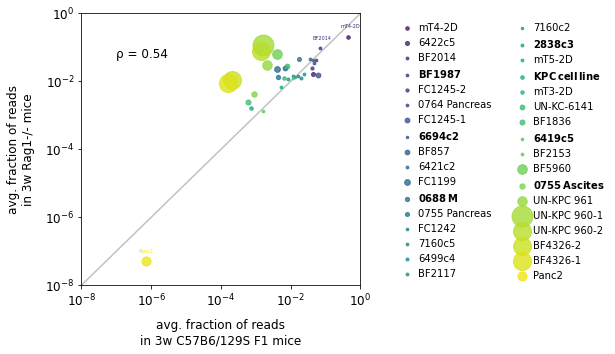

In [39]:
plt.figure(figsize=(5, 5))

superwinners = ['6694c2', 'BF1987', '0688_M', 'FC1245', '6419c5', 'FC1245', 'KPC_cell_line', '0755_Ascites', '2838c3']

x = []; y = []
for count, i in enumerate(order):
    if count < 3: # skipping spike-ins
        continue
        
    # determining the dot size
    diff = max([cell_line_fracs_f1_3w[cell_lines[i]], cell_line_fracs_rag1_3w[cell_lines[i]]]) / min([cell_line_fracs_f1_3w[cell_lines[i]], cell_line_fracs_rag1_3w[cell_lines[i]]]) 
        
    if cell_lines[i] in superwinners: 
        label = "$\\bf{" + cell_lines[i].replace('_', '\,') + "}$"
        # plt.scatter(cell_line_fracs_f1[cell_lines[i]], cell_line_fracs_rag1[cell_lines[i]], facecolors='none', edgecolors='#000000', s=6 * diff)

    else:
        label = cell_lines[i].replace('_', ' ')
        
    plt.scatter(cell_line_fracs_f1_3w[cell_lines[i]], cell_line_fracs_rag1_3w[cell_lines[i]], color=viridis.to_rgba(count), label=label, s=6 * diff, alpha=0.8)
    
    if count in [3, 5, 36]:
        plt.text(0.6 * cell_line_fracs_f1_3w[cell_lines[i]], 1.8 * cell_line_fracs_rag1_3w[cell_lines[i]],
                cell_lines[i], color=viridis.to_rgba(count), size=5)
        
    x.append(cell_line_fracs_f1_3w[cell_lines[i]])
    y.append(cell_line_fracs_rag1_3w[cell_lines[i]])
    
plt.plot([1e-10, 10], [1e-10, 10], color='#c1c1c1', zorder=0)

spearman_r = sp.stats.spearmanr(x, y)
plt.text(1e-7, 0.05, 'ρ = ' + '{0:.2f}'.format(spearman_r[0]), size=12)


plt.xscale('log'); plt.minorticks_off()  
plt.yscale('log'); plt.minorticks_off()
plt.xlim(1e-8, 1);
plt.ylim(1e-8, 1);

plt.xticks(size=12)
plt.yticks(size=12)

plt.xlabel('avg. fraction of reads\nin 3w C57B6/129S F1 mice', fontsize=12, labelpad=10);
plt.ylabel('avg. fraction of reads\nin 3w Rag1-/- mice', fontsize=12, labelpad=10);

plt.legend(frameon=False, ncol=2, handletextpad=0.1, bbox_to_anchor=(1.1, 1));

# plt.savefig('avg_read_frac_per_cell_line-2.png', dpi=300, bbox_inches='tight')

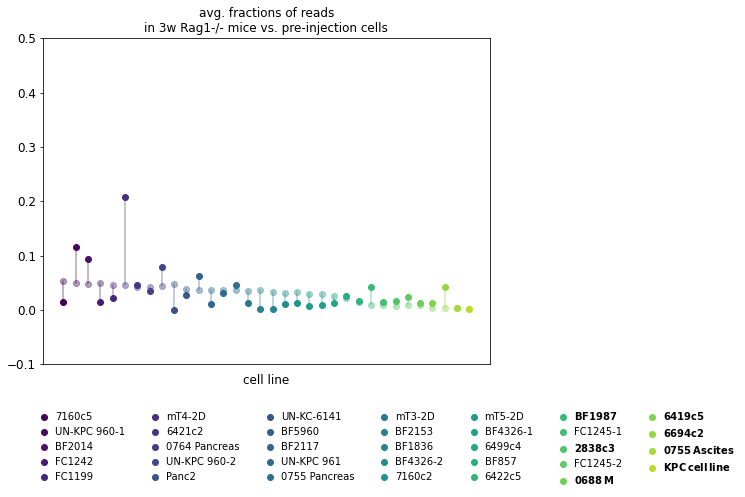

In [270]:
plt.figure(figsize=(8, 6))

diff_rag1 = []

superwinners = ['6694c2', 'BF1987', '0688_M', 'FC1245', '6419c5', 'FC1245', 'KPC_cell_line', '0755_Ascites', '2838c3']

order = [4, 14, 17, 35, 2, 0, 30, 29, 24, 7, 26, 18, 11, 36, 15, 27, 25, 16, 13, 1, 28, 10, 19, 5, 20, 6, 9, 32, 21, 8, 12, 3, 31, 22]

x = []; y = []
for count, i in enumerate(order):
    if i in [23, 33, 34]: # skipping spike-ins
        continue
        
    # determining the dot size
    # diff = max([cell_line_fracs_f1_3w[cell_lines[i]], cell_line_fracs_rag1_3w[cell_lines[i]]]) / min([cell_line_fracs_f1_3w[cell_lines[i]], cell_line_fracs_rag1_3w[cell_lines[i]]]) 
        
    if cell_lines[i] in superwinners: 
        label = "$\\bf{" + cell_lines[i].replace('_', '\,') + "}$"
        # plt.scatter(cell_line_fracs_f1[cell_lines[i]], cell_line_fracs_rag1[cell_lines[i]], facecolors='none', edgecolors='#000000', s=6 * diff)

    else:
        label = cell_lines[i].replace('_', ' ')
        
    plt.scatter(count, cell_line_fracs_rag1_3w[cell_lines[i]], color=viridis.to_rgba(count), label=label, alpha=1)
    plt.scatter(count, cell_line_fracs_pre_inj[cell_lines[i]], color=viridis.to_rgba(count), alpha=0.4)
    plt.plot([count, count], [cell_line_fracs_pre_inj[cell_lines[i]], cell_line_fracs_rag1_3w[cell_lines[i]]], color=viridis.to_rgba(count), alpha=0.4)
    diff_rag1.append([i, cell_line_fracs_rag1_3w[cell_lines[i]] - cell_line_fracs_pre_inj[cell_lines[i]]])
        
    #x.append(cell_line_fracs_f1_3w[cell_lines[i]])
    #y.append(cell_line_fracs_rag1_3w[cell_lines[i]])
    
#plt.plot([1e-10, 10], [1e-10, 10], color='#c1c1c1', zorder=0)


#plt.xscale('log'); plt.minorticks_off()  
#plt.yscale('log'); plt.minorticks_off()
#plt.xlim(1e-8, 1);
plt.ylim(-0.1, 0.5);

plt.xticks([], [])
plt.yticks(size=12)

plt.title('avg. fractions of reads\nin 3w Rag1-/- mice vs. pre-injection cells')

plt.xlabel('cell line', fontsize=12, labelpad=10);
#plt.ylabel('avg. fraction of reads\nin 3w Rag1-/- mice', fontsize=12, labelpad=10);

plt.legend(frameon=False, ncol=7, handletextpad=0.1, loc='lower left', bbox_to_anchor=(-0.04, -0.4));

#plt.savefig('avg_read_frac_3w_rag1_vs_pre-inj.png', dpi=300, bbox_inches='tight')

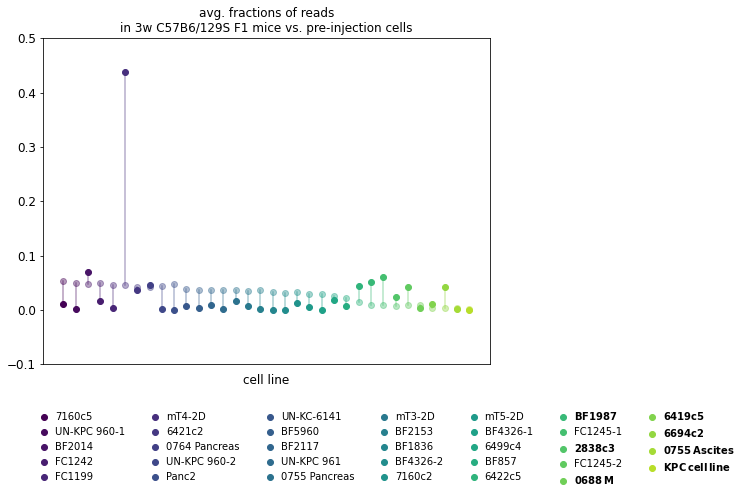

In [271]:
plt.figure(figsize=(8, 6))

diff_f1 = []

superwinners = ['6694c2', 'BF1987', '0688_M', 'FC1245', '6419c5', 'FC1245', 'KPC_cell_line', '0755_Ascites', '2838c3']

order = [4, 14, 17, 35, 2, 0, 30, 29, 24, 7, 26, 18, 11, 36, 15, 27, 25, 16, 13, 1, 28, 10, 19, 5, 20, 6, 9, 32, 21, 8, 12, 3, 31, 22]

x = []; y = []
for count, i in enumerate(order):
    if i in [23, 33, 34]: # skipping spike-ins
        continue
        
    # determining the dot size
    # diff = max([cell_line_fracs_f1_3w[cell_lines[i]], cell_line_fracs_f1_3w[cell_lines[i]]]) / min([cell_line_fracs_f1_3w[cell_lines[i]], cell_line_fracs_f1_3w[cell_lines[i]]]) 
        
    if cell_lines[i] in superwinners: 
        label = "$\\bf{" + cell_lines[i].replace('_', '\,') + "}$"
        # plt.scatter(cell_line_fracs_f1[cell_lines[i]], cell_line_fracs_f1[cell_lines[i]], facecolors='none', edgecolors='#000000', s=6 * diff)

    else:
        label = cell_lines[i].replace('_', ' ')
        
    plt.scatter(count, cell_line_fracs_f1_3w[cell_lines[i]], color=viridis.to_rgba(count), label=label, alpha=1)
    plt.scatter(count, cell_line_fracs_pre_inj[cell_lines[i]], color=viridis.to_rgba(count), alpha=0.4)
    plt.plot([count, count], [cell_line_fracs_pre_inj[cell_lines[i]], cell_line_fracs_f1_3w[cell_lines[i]]], color=viridis.to_rgba(count), alpha=0.4)
    diff_f1.append([i, cell_line_fracs_f1_3w[cell_lines[i]] - cell_line_fracs_pre_inj[cell_lines[i]]])
        
    #x.append(cell_line_fracs_f1_3w[cell_lines[i]])
    #y.append(cell_line_fracs_f1_3w[cell_lines[i]])
    
#plt.plot([1e-10, 10], [1e-10, 10], color='#c1c1c1', zorder=0)


#plt.xscale('log'); plt.minorticks_off()  
#plt.yscale('log'); plt.minorticks_off()
#plt.xlim(1e-8, 1);
plt.ylim(-0.1, 0.5);

plt.xticks([], [])
plt.yticks(size=12)

plt.title('avg. fractions of reads\nin 3w C57B6/129S F1 mice vs. pre-injection cells')

plt.xlabel('cell line', fontsize=12, labelpad=10);
#plt.ylabel('avg. fraction of reads\nin 3w f1-/- mice', fontsize=12, labelpad=10);

plt.legend(frameon=False, ncol=7, handletextpad=0.1, loc='lower left', bbox_to_anchor=(-0.04, -0.4));

# plt.savefig('avg_read_frac_3w_f1_vs_pre-inj.png', dpi=300, bbox_inches='tight')

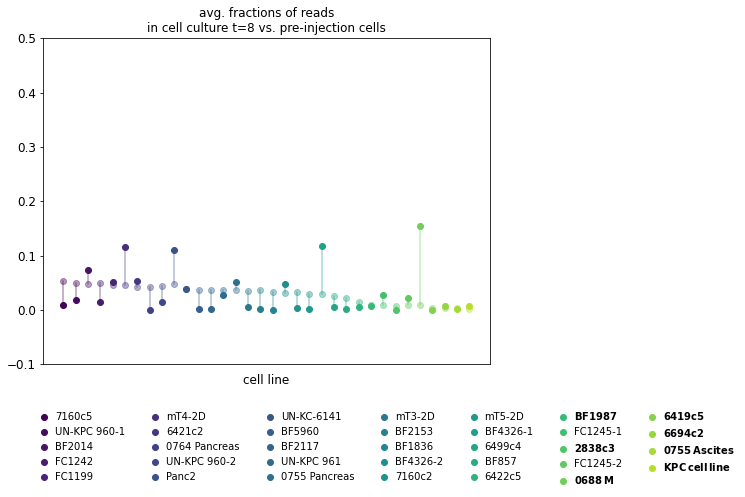

In [272]:
plt.figure(figsize=(8, 6))

diff_t8 = []

superwinners = ['6694c2', 'BF1987', '0688_M', 'FC1245', '6419c5', 'FC1245', 'KPC_cell_line', '0755_Ascites', '2838c3']

order = [4, 14, 17, 35, 2, 0, 30, 29, 24, 7, 26, 18, 11, 36, 15, 27, 25, 16, 13, 1, 28, 10, 19, 5, 20, 6, 9, 32, 21, 8, 12, 3, 31, 22]

x = []; y = []
for count, i in enumerate(order):
    if i in [23, 33, 34]: # skipping spike-ins
        continue
        
    # determining the dot size
    # diff = max([cell_line_fracs_t8[cell_lines[i]], cell_line_fracs_t8[cell_lines[i]]]) / min([cell_line_fracs_t8[cell_lines[i]], cell_line_fracs_t8[cell_lines[i]]]) 
        
    if cell_lines[i] in superwinners: 
        label = "$\\bf{" + cell_lines[i].replace('_', '\,') + "}$"
        # plt.scatter(cell_line_fracs_f1[cell_lines[i]], cell_line_fracs_f1[cell_lines[i]], facecolors='none', edgecolors='#000000', s=6 * diff)

    else:
        label = cell_lines[i].replace('_', ' ')
        
    plt.scatter(count, cell_line_fracs_t8[cell_lines[i]], color=viridis.to_rgba(count), label=label, alpha=1)
    plt.scatter(count, cell_line_fracs_pre_inj[cell_lines[i]], color=viridis.to_rgba(count), alpha=0.4)
    plt.plot([count, count], [cell_line_fracs_pre_inj[cell_lines[i]], cell_line_fracs_t8[cell_lines[i]]], color=viridis.to_rgba(count), alpha=0.4)
    diff_t8.append([i, cell_line_fracs_t8[cell_lines[i]] - cell_line_fracs_pre_inj[cell_lines[i]]])
        
    #x.append(cell_line_fracs_t8[cell_lines[i]])
    #y.append(cell_line_fracs_t8[cell_lines[i]])
    
#plt.plot([1e-10, 10], [1e-10, 10], color='#c1c1c1', zorder=0)


#plt.xscale('log'); plt.minorticks_off()  
#plt.yscale('log'); plt.minorticks_off()
#plt.xlim(1e-8, 1);
plt.ylim(-0.1, 0.5);

plt.xticks([], [])
plt.yticks(size=12)

plt.title('avg. fractions of reads\nin cell culture t=8 vs. pre-injection cells')

plt.xlabel('cell line', fontsize=12, labelpad=10);
#plt.ylabel('avg. fraction of reads\nin 3w f1-/- mice', fontsize=12, labelpad=10);

plt.legend(frameon=False, ncol=7, handletextpad=0.1, loc='lower left', bbox_t8o_anchor=(-0.04, -0.4));

#plt.savefig('avg_read_frac_t8_vs_pre-inj.png', dpi=300, bbox_inches='tight')

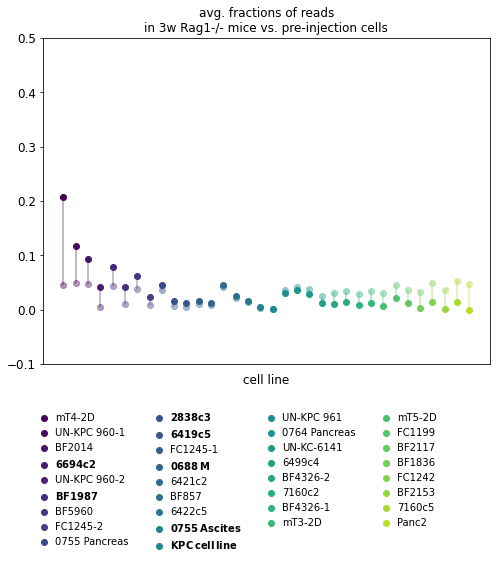

In [337]:
plt.figure(figsize=(8, 6))


superwinners = ['6694c2', 'BF1987', '0688_M', 'FC1245', '6419c5', 'FC1245', 'KPC_cell_line', '0755_Ascites', '2838c3']

order = [x[0] for x in sorted(diff_rag1, key = lambda x: x[-1], reverse=True)]

x = []; y = []
for count, i in enumerate(order):
    if i in [23, 33, 34]: # skipping spike-ins
        continue
        
    # determining the dot size
    # diff = max([cell_line_fracs_f1_3w[cell_lines[i]], cell_line_fracs_rag1_3w[cell_lines[i]]]) / min([cell_line_fracs_f1_3w[cell_lines[i]], cell_line_fracs_rag1_3w[cell_lines[i]]]) 
        
    if cell_lines[i] in superwinners: 
        label = "$\\bf{" + cell_lines[i].replace('_', '\,') + "}$"
        # plt.scatter(cell_line_fracs_f1[cell_lines[i]], cell_line_fracs_rag1[cell_lines[i]], facecolors='none', edgecolors='#000000', s=6 * diff)

    else:
        label = cell_lines[i].replace('_', ' ')
        
    plt.scatter(count, cell_line_fracs_rag1_3w[cell_lines[i]], color=viridis.to_rgba(count), label=label, alpha=1)
    plt.scatter(count, cell_line_fracs_pre_inj[cell_lines[i]], color=viridis.to_rgba(count), alpha=0.4)
    plt.plot([count, count], [cell_line_fracs_pre_inj[cell_lines[i]], cell_line_fracs_rag1_3w[cell_lines[i]]], color=viridis.to_rgba(count), alpha=0.4)
            
    #x.append(cell_line_fracs_f1_3w[cell_lines[i]])
    #y.append(cell_line_fracs_rag1_3w[cell_lines[i]])
    
#plt.plot([1e-10, 10], [1e-10, 10], color='#c1c1c1', zorder=0)


#plt.xscale('log'); plt.minorticks_off()  
#plt.yscale('log'); plt.minorticks_off()
#plt.xlim(1e-8, 1);
plt.ylim(-0.1, 0.5);

plt.xticks([], [])
plt.yticks(size=12)

plt.title('avg. fractions of reads\nin 3w Rag1-/- mice vs. pre-injection cells')

plt.xlabel('cell line', fontsize=12, labelpad=10);
#plt.ylabel('avg. fraction of reads\nin 3w Rag1-/- mice', fontsize=12, labelpad=10);

plt.legend(frameon=False, ncol=4, handletextpad=0.1, loc='lower left', bbox_to_anchor=(-0.04, -0.6));

#plt.savefig('avg_read_frac_3w_rag1_vs_pre-inj_sorted.png', dpi=300, bbox_inches='tight')

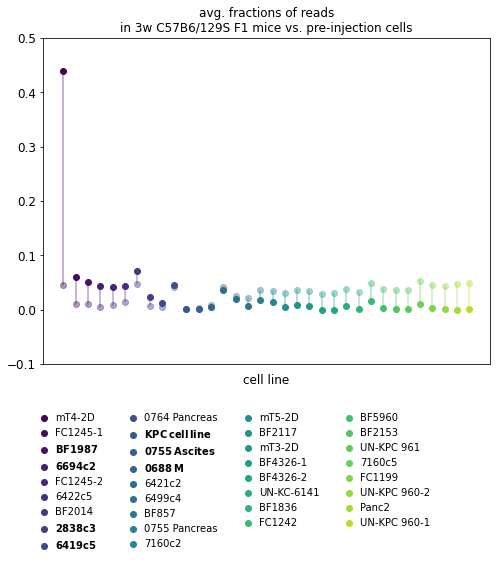

In [274]:
plt.figure(figsize=(8, 6))


superwinners = ['6694c2', 'BF1987', '0688_M', 'FC1245', '6419c5', 'FC1245', 'KPC_cell_line', '0755_Ascites', '2838c3']

order = [x[0] for x in sorted(diff_f1, key = lambda x: x[-1], reverse=True)]

x = []; y = []
for count, i in enumerate(order):
    if i in [23, 33, 34]: # skipping spike-ins
        continue
        
    # determining the dot size
    # diff = max([cell_line_fracs_f1_3w[cell_lines[i]], cell_line_fracs_f1_3w[cell_lines[i]]]) / min([cell_line_fracs_f1_3w[cell_lines[i]], cell_line_fracs_f1_3w[cell_lines[i]]]) 
        
    if cell_lines[i] in superwinners: 
        label = "$\\bf{" + cell_lines[i].replace('_', '\,') + "}$"
        # plt.scatter(cell_line_fracs_f1[cell_lines[i]], cell_line_fracs_f1[cell_lines[i]], facecolors='none', edgecolors='#000000', s=6 * diff)

    else:
        label = cell_lines[i].replace('_', ' ')
        
    plt.scatter(count, cell_line_fracs_f1_3w[cell_lines[i]], color=viridis.to_rgba(count), label=label, alpha=1)
    plt.scatter(count, cell_line_fracs_pre_inj[cell_lines[i]], color=viridis.to_rgba(count), alpha=0.4)
    plt.plot([count, count], [cell_line_fracs_pre_inj[cell_lines[i]], cell_line_fracs_f1_3w[cell_lines[i]]], color=viridis.to_rgba(count), alpha=0.4)
    #diff_f1.append([i, cell_line_fracs_f1_3w[cell_lines[i]] - cell_line_fracs_pre_inj[cell_lines[i]]])
        
    #x.append(cell_line_fracs_f1_3w[cell_lines[i]])
    #y.append(cell_line_fracs_f1_3w[cell_lines[i]])
    
#plt.plot([1e-10, 10], [1e-10, 10], color='#c1c1c1', zorder=0)


#plt.xscale('log'); plt.minorticks_off()  
#plt.yscale('log'); plt.minorticks_off()
#plt.xlim(1e-8, 1);
plt.ylim(-0.1, 0.5);

plt.xticks([], [])
plt.yticks(size=12)

plt.title('avg. fractions of reads\nin 3w C57B6/129S F1 mice vs. pre-injection cells')

plt.xlabel('cell line', fontsize=12, labelpad=10);
#plt.ylabel('avg. fraction of reads\nin 3w f1-/- mice', fontsize=12, labelpad=10);

plt.legend(frameon=False, ncol=4, handletextpad=0.1, loc='lower left', bbox_to_anchor=(-0.04, -0.6));

#plt.savefig('avg_read_frac_3w_f1_vs_pre-inj_sorted.png', dpi=300, bbox_inches='tight')

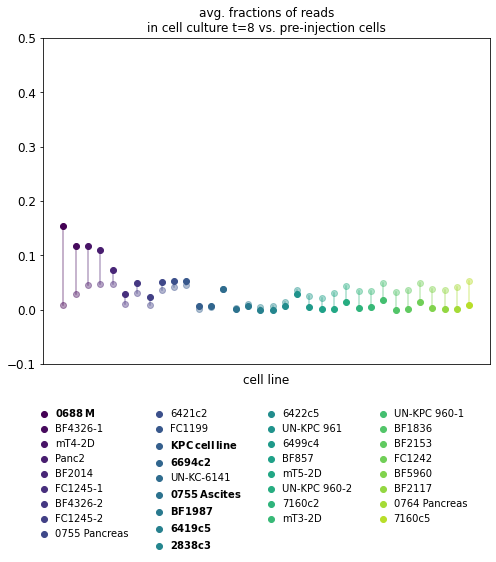

In [276]:
plt.figure(figsize=(8, 6))


superwinners = ['6694c2', 'BF1987', '0688_M', 'FC1245', '6419c5', 'FC1245', 'KPC_cell_line', '0755_Ascites', '2838c3']

order = [x[0] for x in sorted(diff_t8, key = lambda x: x[-1], reverse=True)]

x = []; y = []
for count, i in enumerate(order):
    if i in [23, 33, 34]: # skipping spike-ins
        continue
        
    # determining the dot size
    # diff = max([cell_line_fracs_t8[cell_lines[i]], cell_line_fracs_t8[cell_lines[i]]]) / min([cell_line_fracs_t8[cell_lines[i]], cell_line_fracs_t8[cell_lines[i]]]) 
        
    if cell_lines[i] in superwinners: 
        label = "$\\bf{" + cell_lines[i].replace('_', '\,') + "}$"
        # plt.scatter(cell_line_fracs_f1[cell_lines[i]], cell_line_fracs_f1[cell_lines[i]], facecolors='none', edgecolors='#000000', s=6 * diff)

    else:
        label = cell_lines[i].replace('_', ' ')
        
    plt.scatter(count, cell_line_fracs_t8[cell_lines[i]], color=viridis.to_rgba(count), label=label, alpha=1)
    plt.scatter(count, cell_line_fracs_pre_inj[cell_lines[i]], color=viridis.to_rgba(count), alpha=0.4)
    plt.plot([count, count], [cell_line_fracs_pre_inj[cell_lines[i]], cell_line_fracs_t8[cell_lines[i]]], color=viridis.to_rgba(count), alpha=0.4)
    #diff_f1.append([i, cell_line_fracs_t8[cell_lines[i]] - cell_line_fracs_pre_inj[cell_lines[i]]])
        
    #x.append(cell_line_fracs_t8[cell_lines[i]])
    #y.append(cell_line_fracs_t8[cell_lines[i]])
    
#plt.plot([1e-10, 10], [1e-10, 10], color='#c1c1c1', zorder=0)


#plt.xscale('log'); plt.minorticks_off()  
#plt.yscale('log'); plt.minorticks_off()
#plt.xlim(1e-8, 1);
plt.ylim(-0.1, 0.5);

plt.xticks([], [])
plt.yticks(size=12)

plt.title('avg. fractions of reads\nin cell culture t=8 vs. pre-injection cells')

plt.xlabel('cell line', fontsize=12, labelpad=10);
#plt.ylabel('avg. fraction of reads\nin 3w f1-/- mice', fontsize=12, labelpad=10);

plt.legend(frameon=False, ncol=4, handletextpad=0.1, loc='lower left', bbox_t8o_anchor=(-0.04, -0.6));

#plt.savefig('avg_read_frac_t8_vs_pre-inj_sorted.png', dpi=300, bbox_inches='tight')

IndexError: list index out of range

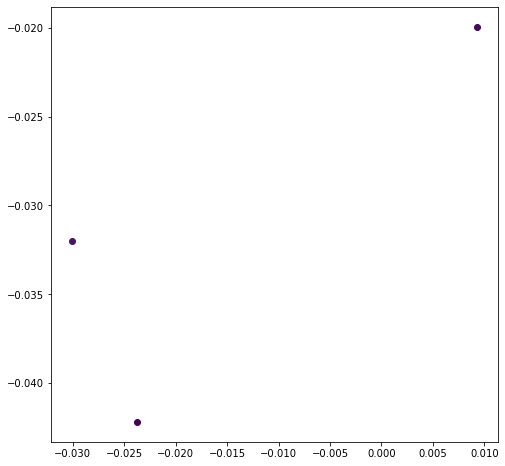

In [358]:
plt.figure(figsize=(8, 8))

superwinners = ['6694c2', 'BF1987', '0688_M', 'FC1245', '6419c5', 'FC1245', 'KPC_cell_line', '0755_Ascites', '2838c3']

order = [4, 14, 17, 35, 2, 0, 30, 29, 24, 7, 26, 18, 11, 36, 15, 27, 25, 16, 13, 1, 28, 10, 19, 5, 20, 6, 9, 32, 21, 8, 12, 3, 31, 22]

for count, i in enumerate(order):
    if i in [23, 33, 34]: # skipping spike-ins
        continue
    
    if cell_lines[i] in superwinners: 
        label = "$\\bf{" + cell_lines[i].replace('_', '\,') + "}$"
       
    else:
        label = cell_lines[i].replace('_', ' ')
        
    plt.scatter(diff_rag1[i][-1], diff_f1[i][-1], color=viridis.to_rgba(count), label=label, alpha=1)
    
plt.plot([-1, 1], [-1, 1], color='#d1d1d1', zorder=0)

plt.xlim(-0.1, 0.5)
plt.ylim(-0.1, 0.5)


In [313]:
timeline = {}
for i in cell_lines:
    if cell_lines.index(i) in [23, 33, 34]:
        continue
        
    timeline[i] = [cell_line_fracs_pre_inj[i]]
    for t in range(0, 8):
        timeline[i].append(cell_line_fracs_t[t + 1][i])
    

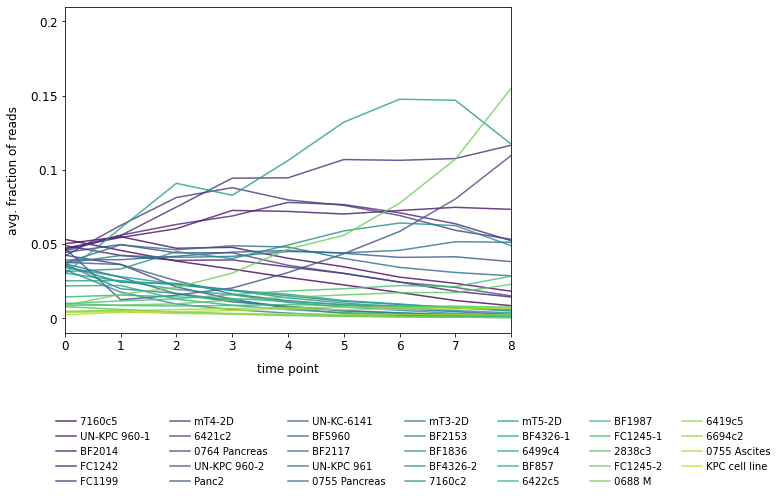

In [336]:
plt.figure(figsize=(8, 6))

order = [4, 14, 17, 35, 2, 0, 30, 29, 24, 7, 26, 18, 11, 36, 15, 27, 25, 16, 13, 1, 28, 10, 19, 5, 20, 6, 9, 32, 21, 8, 12, 3, 31, 22]

for count, i in enumerate(order):
    plt.plot(range(0, 9), timeline[cell_lines[i]], color=viridis.to_rgba(count), alpha=0.8, label=' ' + cell_lines[i].replace('_', ' '))
    
plt.xlim(0,8)
plt.ylim(-0.01, 0.21)

plt.xticks(size=12)
plt.yticks([0, 0.05, 0.1, 0.15, 0.2], ['$0$', '$0.05$', '$0.1$', '$0.15$', '$0.2$'], size=12)

plt.xlabel('time point', fontsize=12, labelpad=10);
plt.ylabel('avg. fraction of reads', fontsize=12, labelpad=10);
    
plt.legend(frameon=False, ncol=7, handletextpad=0.1, loc='lower left', bbox_to_anchor=(-0.04, -0.5)); 

# plt.savefig('cell_line_trj.png', dpi=300, bbox_inches='tight')

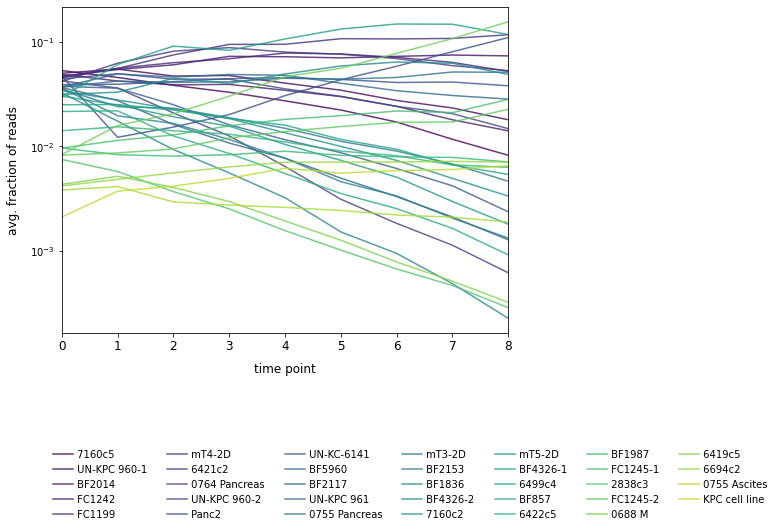

In [334]:
plt.figure(figsize=(8, 6))

order = [4, 14, 17, 35, 2, 0, 30, 29, 24, 7, 26, 18, 11, 36, 15, 27, 25, 16, 13, 1, 28, 10, 19, 5, 20, 6, 9, 32, 21, 8, 12, 3, 31, 22]

for count, i in enumerate(order):
    plt.plot(range(0, 9), timeline[cell_lines[i]], color=viridis.to_rgba(count), alpha=0.8, label=' ' + cell_lines[i].replace('_', ' '))
    
    
plt.yscale('log'); plt.minorticks_off()  

plt.xlim(0,8)
#plt.ylim(-0.01, 0.21)

plt.xticks(size=12)
#plt.yticks([0, 0.05, 0.1, 0.15, 0.2], ['$0$', '$0.05$', '$0.1$', '$0.15$', '$0.2$'], size=12)

plt.xlabel('time point', fontsize=12, labelpad=10);
plt.ylabel('avg. fraction of reads', fontsize=12, labelpad=10);
    
plt.legend(frameon=False, ncol=7, handletextpad=0.1, loc='lower left', bbox_to_anchor=(-0.04, -0.6)); 

#plt.savefig('cell_line_trj_log.png', dpi=300, bbox_inches='tight')


In [ ]:
# fraction of barcodes present for each cell line in each sample:

In [135]:
# pooling all barcodes for pre-injection cells (intersection):
pre_inj_bc_cell_line_dict = {}

for i in clIDs:
    
    if clIDs.index(i) in [23, 33, 34]: # skipping spike-ins
        continue
        
    pre_inj_bc_cell_line_dict[i] = list(set([x[0] for x in sample_clID_counts_pre_inj[0][i]]).intersection(set([x[0] for x in sample_clID_counts_pre_inj[1][i]])).intersection(set([x[0] for x in sample_clID_counts_pre_inj[2][i]])))
    

In [136]:
pre_inj_bc_cell_line_missing_frac = []

for i in range(3):
    
    pre_inj_bc_cell_line_missing_frac_i = {}
    
    for j in clIDs:
        
        if clIDs.index(j) in [23, 33, 34]: # skipping spike-ins
            continue
        
        pre_inj_bc_cell_line_missing_frac_i[j] = len([x[0] for x in sample_clID_counts_pre_inj[i][j] if x[0] not in pre_inj_bc_cell_line_dict[j]]) / len(sample_clID_counts_pre_inj[i][j])
     
    pre_inj_bc_cell_line_missing_frac.append(pre_inj_bc_cell_line_missing_frac_i)
        

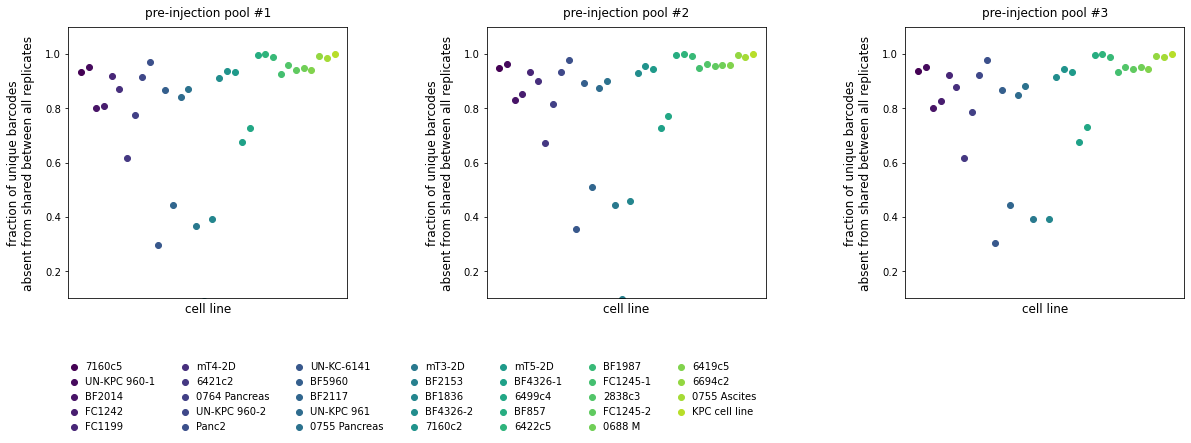

In [146]:
viridis = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=len(cell_lines)), 
                                       cmap=plt.get_cmap('viridis'))

plasma = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(vmin=0, vmax=5), 
                                       cmap=plt.get_cmap('plasma'))

colors = ['#b83089', '#da5a67', '#ec7a52'] # for spike-ins

plt.figure(figsize=(20, 5))

grid = gridspec.GridSpec(ncols=3, nrows=1,
                         width_ratios=[1, 1, 1], wspace=0.5,
                         height_ratios=[1], hspace=0.5)

c = 0
cell_line_fracs_sample = []
for i in range(len(samples_pre_inj[:3])):
    
    plt.subplot(grid[c // 3, c % 3])
    
        
    # cell line order based on sample 1 - not the same as before!!!
    order = [4, 14, 17, 35, 2, 0, 30, 29, 24, 7, 26, 18, 11, 36, 15, 27, 25, 16, 13, 1, 28, 10, 19, 5, 20, 6, 9, 32, 21, 8, 12, 3, 31, 22, 34, 23, 33]
    
    for count, j in enumerate(order):
        
        if cell_lines[j][:5] != 'Spike':
            plt.scatter(count, pre_inj_bc_cell_line_missing_frac[i][clIDs[j]], label=cell_lines[j].replace('_', ' '), color=viridis.to_rgba(count))
    
    #plt.yscale('log'); plt.minorticks_off()
    plt.ylim(0.1, 1.1)
    # plt.xlim(0, 200)
    # plt.yticks([1, 500, 1000, 1500, 2000], ['$0$', '$500$', '$1000$', '$1500$', '$2000$'], fontsize=10)
    plt.xticks([], [])
    
    if i == 1:
        plt.legend(frameon=False, ncol=7, handletextpad=0.1, bbox_to_anchor=(1, -0.2))
    
    
    plt.title('pre-injection pool #' + str(i + 1), fontsize=12, pad=10)
    plt.xlabel('cell line', fontsize=12)
    plt.ylabel('fraction of unique barcodes\nabsent from shared between all replicates', fontsize=12, labelpad=10)
      
    c += 1

    # plt.savefig('pre-inj_frac_bc_absent.png', dpi=300, bbox_inches='tight')

In [233]:
n_reads = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
n_reads_bc_rep1 = {}

for n in n_reads:
    
    n_reads_bc_rep1_n = {}

    for i in clIDs:
        if i in [23, 33, 34]:
            continue
            
        n_reads_bc_rep1_n[i] = [x[0] for x in sample_clID_counts_pre_inj[0][i] if x[1] == n]
        
    n_reads_bc_rep1[n] = n_reads_bc_rep1_n

In [234]:
n_reads_counts_rep3_merged = {}

for n in n_reads:
    
    counts_n = {}
    
    for i in clIDs:
        if i in [23, 33, 34]:
            continue
        counts_i = {}
        
        ns = [dict(sample_clID_counts_pre_inj[2][i]).get(x) for x in n_reads_bc_rep1[n][i]]
        ns_count = dict([[0 if y is None else y for y in [x, ns.count(x)]] for x in set(ns)])
        
        for x in ns_count.keys():
            if x not in counts_n.keys():
                counts_n[x] = 0
                
            counts_n[x] += ns_count[x]              
        
        
    n_reads_counts_rep3_merged[n] = list(counts_n.items())
   

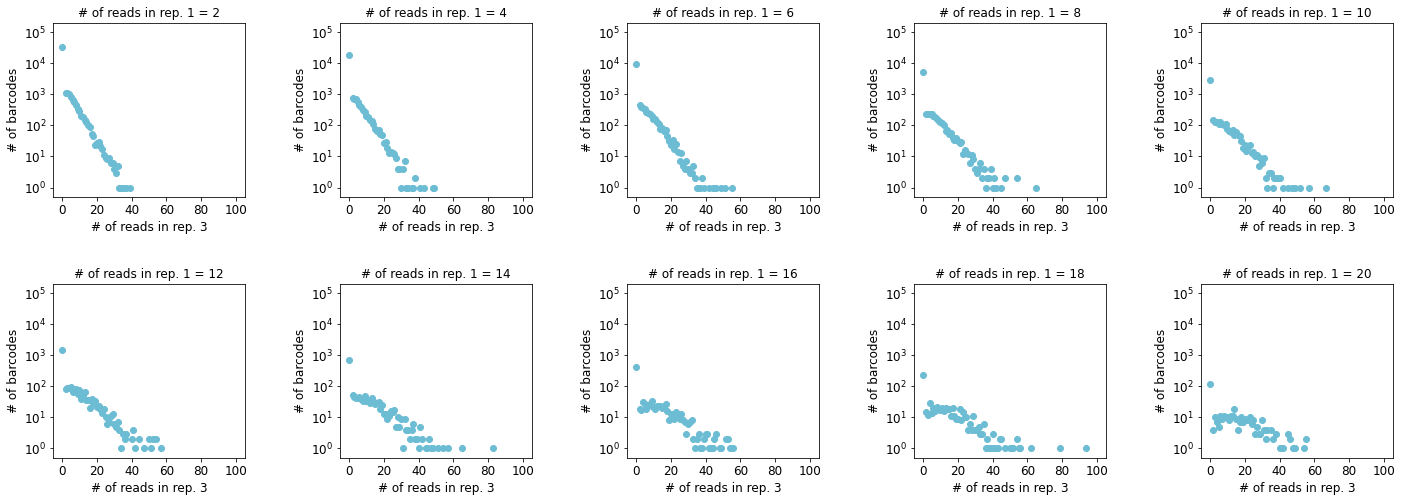

In [252]:
plt.figure(figsize=(24, 8))

grid = gridspec.GridSpec(ncols=5, nrows=2,
                         width_ratios=[1, 1, 1, 1, 1], wspace=0.5,
                         height_ratios=[1, 1], hspace=0.5)

c = 0
for n in n_reads:
    
    plt.subplot(grid[c // 5, c % 5])
    
    # drawing read counts from a Poisson distribution:
    #draws = list(np.random.poisson(n * R_mut_2 / R_mut_1, sum([x[1] for x in n_reads_reads_2_merged[n]])))
    #draws_counts = [[x, draws.count(x)] for x in set(draws)]
    
    #plt.scatter([x[0] for x in draws_counts], [x[1] for x in draws_counts], color='#e0e055')
    plt.scatter([x[0] for x in n_reads_counts_rep3_merged[n]], [x[1] for x in n_reads_counts_rep3_merged[n]], color='#6cbdd4')
    plt.yscale('log'); plt.minorticks_off()
    
    plt.ylim(0.5, 2e5)
    plt.xlim(-5, 105)
    
    plt.xticks(size=12)
    plt.yticks(size=12)
    
    plt.xlabel('# of reads in rep. 3', fontsize=12)
    plt.ylabel('# of barcodes', fontsize=12)
    plt.title('# of reads in rep. 1 = ' + str(n), fontsize=12)
    
    c += 1
    
plt.savefig('pre-inj_levy_blundell_fig15.png', dpi=300, bbox_inches='tight')    